# Pipeline de Navegacao por Flow Optico + IMU
### Etapas: Leitura -> SI -> Bias -> Filtro -> Media -> Madgwick -> Gravidade -> **Flow/ToF (primario em XY)** -> IMU Dead Reckoning (backup nos gaps) -> Posicao XY

| Parametro | Valor |
|-----------|-------|
| Arquivo | `dados.csv` |
| Sensores principais | Flow optico (`flow_dx`/`flow_dy` em cm) + ToF (`tof_mm` em mm) para correcao de escala |
| Sensores de backup | 2x IMU (acelerometro + giroscopio) |
| Estrategia | Flow/ToF como fonte primaria de posicao no plano XY; IMU integrada apenas nos gaps do flow |
| Escopo do estudo | Posicao horizontal nos eixos X e Y |

## Justificativa da Arquitetura

O sensor de fluxo optico mede deslocamento diretamente da superficie, sem integracao de ruido. Seu erro cresce **linearmente** com a distancia percorrida. A IMU, apos dupla integracao, acumula erro proporcional a `0.5*sigma_a*t^2`, com crescimento **quadratico**. Para distancias tipicas de robotica indoor (< 10 m), o sensor optico e ordens de grandeza mais preciso em posicao absoluta.

O eixo Z foi retirado do estudo de posicao. Para obter uma estimativa precisa da posicao vertical seria necessario um segundo sensor optico posicionado para observar o plano **XZ** em relacao ao drone. O sensor optico atual observa o plano horizontal e fornece deslocamento confiavel apenas em XY; o ToF mede distancia ao solo e pode corrigir a escala do flow, mas nao substitui uma odometria optica dedicada para o eixo Z.

O IMU e mantido no pipeline para dois papeis complementares:
1. **Orientacao (Madgwick):** necessaria para estimar a atitude do drone e remover a componente gravitacional da aceleracao
2. **Dead reckoning nos gaps:** quando o flow nao reporta evento (movimento abaixo de ~11 cm/s ou descontinuidade do sensor), a IMU preenche a trajetoria XY entre os dois ultimos pontos conhecidos

**Filtros removidos em relacao a versao anterior:**

| Filtro removido | Motivo |
|---|---|
| PSD knee detection | Desnecessario: fc fixo e suficiente com flow como primario |
| Correcao centripeta/tangencial | Efeito < 1 mm para o offset presente; abaixo da resolucao do flow |
| ZARU | Dependia de IMU como fonte primaria de orientacao acumulada |
| ABC (Acceleration Bias Correction) | Drift do accel em posicao e irrelevante quando flow corrige |
| ZUPT (Zero Velocity Update) | Substituido por ancoragem direta nos eventos de flow |


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, sosfiltfilt
from scipy.spatial.transform import Rotation as Rot
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 10, 'font.size': 10, 'lines.linewidth': 1.2,
})
print('Imports OK')


Imports OK


## ⚙️ Parâmetros

In [26]:
# ── IMU ──────────────────────────────────────────────────────────────────────
G_NORM       = 9.81              # m/s²
ACCEL_SCALE  = G_NORM / 16384.0  # ±2 g → 16384 LSB/g
GYRO_SCALE   = (1.0/131.0) * (np.pi/180.0)  # ±250 °/s → 131 LSB/(°/s)

ACCEL_SAT_THRESH = 32600  # LSB — saturação do acelerômetro
GYRO_SAT_THRESH  = 32600  # LSB — saturação do giroscópio

T_CALIB      = 5.0   # s — janela de repouso para calibração de bias

# Frequência de corte do filtro Butterworth (Hz)
# Valor único por tipo de sensor — sem PSD knee detection.
# Objetivo: suavizar ruído de quantização sem atenuar dinâmica real.
FC_ACCEL = 5.0   # Hz — acelerômetro
FC_GYRO  = 5.0   # Hz — giroscópio

# Parâmetro beta do Madgwick — balanço entre integração do gyro e correção pelo accel
# Será calculado automaticamente a partir do ruído do gyro na janela de calibração
MADGWICK_BETA = None  # calculado na etapa 5

# ── Flow Óptico + ToF ────────────────────────────────────────────────────────
# O flow entrega deslocamento incremental já em cm (firmware pré-escalado pela
# altura nominal). O ToF corrige desvios quando a altura real difere da nominal.
TOF_VALID_MIN_MM = 20    # mm — abaixo disso: leitura inválida (eco ausente)
TOF_VALID_MAX_MM = 300   # mm — acima disso: fora do alcance
TOF_NOMINAL_MM   = 90.0  # mm — altura de referência usada pelo firmware

# Mapeamento de eixos flow → referencial mundo IMU
# Ajuste se os eixos do sensor óptico estiverem girados em relação ao IMU.
# 'x' = mesmo sentido, '-x' = sentido invertido.
FLOW_AXIS_X = 'x'   # flow_dx → X mundo
FLOW_AXIS_Y = 'y'   # flow_dy → Y mundo

# ── Dead reckoning (IMU nos gaps do flow) ───────────────────────────────────
# Peso de confiança da IMU na interpolação dos gaps (0=posição zero, 1=IMU livre)
# Um valor < 1 suaviza a ancoragem forçada aos pontos de flow.
IMU_GAP_WEIGHT = 1.0

FILE_PATH = './dados.csv'

print(f'ACCEL_SCALE = {ACCEL_SCALE:.6f} m/s²/LSB')
print(f'GYRO_SCALE  = {GYRO_SCALE:.8f} rad/s/LSB')
print(f'FC_ACCEL={FC_ACCEL} Hz  FC_GYRO={FC_GYRO} Hz')


ACCEL_SCALE = 0.000599 m/s²/LSB
GYRO_SCALE  = 0.00013323 rad/s/LSB
FC_ACCEL=5.0 Hz  FC_GYRO=5.0 Hz


## 1️⃣ Ler CSV e Verificar Colunas

In [27]:
df_raw = pd.read_csv(FILE_PATH)
print(f'Linhas totais: {len(df_raw):,}')
print(f'Colunas: {list(df_raw.columns)}')
print()
display(df_raw.head(3))

for col in ['tof_mm', 'flow_dx', 'flow_dy']:
    if col not in df_raw.columns:
        raise ValueError(f'Coluna ausente: {col}')
print('Colunas de fusao presentes: tof_mm, flow_dx, flow_dy')
print()
print('Estatísticas dos sensores opticos:')
print(df_raw[['tof_mm','flow_dx','flow_dy']].describe().round(2))


Linhas totais: 6,241
Colunas: ['tempo_us', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'angle', 'distance', 'intensity', 'tof_mm', 'flow_dx', 'flow_dy']



,tempo_us,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,gy2,gz2,angle,distance,intensity,tof_mm,flow_dx,flow_dy
0,11417907,117,-4115,15982,-2,-132,-157,-513,-3916,15985,-95,-552,-452,1197,11328,168,90,0,0
1,11417907,117,-4115,15982,-2,-132,-157,-513,-3916,15985,-95,-552,-452,4574,48113,2,90,0,0
2,11417907,117,-4115,15982,-2,-132,-157,-513,-3916,15985,-95,-552,-452,7952,44019,109,90,0,0


Colunas de fusao presentes: tof_mm, flow_dx, flow_dy

Estatísticas dos sensores opticos:
        tof_mm  flow_dx  flow_dy
count  6241.00  6241.00  6241.00
mean     89.42     0.05     1.41
std       3.34     0.29     3.22
min       1.00    -1.00     0.00
25%      87.00     0.00     0.00
50%      89.00     0.00     0.00
75%      91.00     0.00     0.00
max      99.00     2.00    16.00


## 2️⃣ Deduplicar Timestamps e Converter Tempo

Amostras após deduplicação: 521 (removidas: 5720)
Duração total: 52.066 s
Fs mediana: 10.82 Hz | dt mediano: 92.42 ms
dt mín: 60.45 ms | dt máx: 1185.38 ms


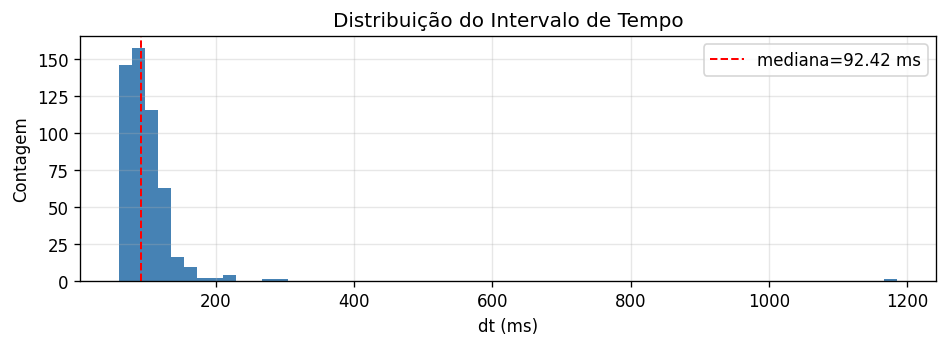

In [28]:
df = df_raw.drop_duplicates(subset=['tempo_us']).reset_index(drop=True).copy()
print(f'Amostras após deduplicação: {len(df):,} (removidas: {len(df_raw)-len(df)})')

t0 = df['tempo_us'].values[0]
df['t_s'] = (df['tempo_us'].values - t0) / 1e6
df = df[df['t_s'] >= 0]
t   = df['t_s'].values
N   = len(t)

dt_arr  = np.diff(t)
Fs      = 1.0 / np.median(dt_arr)
dt_med  = np.median(dt_arr)

print(f'Duração total: {t[-1]:.3f} s')
print(f'Fs mediana: {Fs:.2f} Hz | dt mediano: {dt_med*1000:.2f} ms')
print(f'dt mín: {dt_arr.min()*1000:.2f} ms | dt máx: {dt_arr.max()*1000:.2f} ms')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(dt_arr * 1000, bins=60, color='steelblue', edgecolor='none')
ax.axvline(dt_med*1000, color='red', ls='--', label=f'mediana={dt_med*1000:.2f} ms')
ax.set_xlabel('dt (ms)'); ax.set_ylabel('Contagem')
ax.set_title('Distribuição do Intervalo de Tempo'); ax.legend()
plt.tight_layout(); plt.show()


## 3️⃣ Converter para SI e Detectar Saturação

In [29]:
# Acelerações (m/s²)
ax1_si = df['ax1'].values * ACCEL_SCALE;  ay1_si = df['ay1'].values * ACCEL_SCALE
az1_si = df['az1'].values * ACCEL_SCALE
ax2_si = df['ax2'].values * ACCEL_SCALE;  ay2_si = df['ay2'].values * ACCEL_SCALE
az2_si = df['az2'].values * ACCEL_SCALE

# Giroscópios (rad/s)
gx1_si = df['gx1'].values * GYRO_SCALE;  gy1_si = df['gy1'].values * GYRO_SCALE
gz1_si = df['gz1'].values * GYRO_SCALE
gx2_si = df['gx2'].values * GYRO_SCALE;  gy2_si = df['gy2'].values * GYRO_SCALE
gz2_si = df['gz2'].values * GYRO_SCALE

# Saturação
accel_cols = ['ax1','ay1','az1','ax2','ay2','az2']
gyro_cols  = ['gx1','gy1','gz1','gx2','gy2','gz2']
sat_accel  = (df[accel_cols].abs() >= ACCEL_SAT_THRESH).any(axis=1).values
sat_gyro   = (df[gyro_cols].abs()  >= GYRO_SAT_THRESH ).any(axis=1).values
sat_any    = sat_accel | sat_gyro
df['sat']  = sat_any

print(f'Saturação accel: {sat_accel.sum()} amostras ({100*sat_accel.mean():.2f}%)')
print(f'Saturação gyro : {sat_gyro.sum()} amostras ({100*sat_gyro.mean():.2f}%)')

# Verificação em repouso
mask_v = t <= T_CALIB
print(f'Amostras de calibração ({T_CALIB}s): {mask_v.sum()}')
print('Eixo           média      std')
for name, arr in [('ax1(m/s²)',ax1_si),('ay1',ay1_si),('az1',az1_si),
                   ('gx1(°/s)',gx1_si*180/np.pi),('gy1',gy1_si*180/np.pi),
                   ('gz1',gz1_si*180/np.pi)]:
    print(f'  {name:15s}: {arr[mask_v].mean():+.4f}   {arr[mask_v].std():.4f}')


Saturação accel: 0 amostras (0.00%)
Saturação gyro : 0 amostras (0.00%)
Amostras de calibração (5.0s): 49
Eixo           média      std
  ax1(m/s²)      : -0.0083   0.0458
  ay1            : -2.5167   0.0333
  az1            : +9.5371   0.0385
  gx1(°/s)       : -0.2050   0.1728
  gy1            : -0.9752   0.1119
  gz1            : -1.3078   0.0882


## 4️⃣ Calibração de Bias (janela estática inicial)

Durante os primeiros `T_CALIB` segundos o dispositivo está em repouso. A média de cada eixo é subtraída como bias estático. O eixo Z do acelerômetro deve medir `+g` em repouso — o bias é calculado em relação a esse valor esperado.

> Este passo é mantido pois o Madgwick precisa de um giroscópio com bias residual mínimo para convergir corretamente para a orientação real.


In [30]:
mask_calib = t <= T_CALIB

# MANTENHA APENAS A CALIBRAÇÃO DO GIROSCÓPIO
bias_gx1 = gx1_si[mask_calib].mean()
bias_gy1 = gy1_si[mask_calib].mean()
bias_gz1 = gz1_si[mask_calib].mean()
bias_gx2 = gx2_si[mask_calib].mean()
bias_gy2 = gy2_si[mask_calib].mean()
bias_gz2 = gz2_si[mask_calib].mean()

# ACELERÔMETRO VAI DIRETO (sem subtrair bias)
ax1_cal = ax1_si;  ay1_cal = ay1_si;  az1_cal = az1_si
ax2_cal = ax2_si;  ay2_cal = ay2_si;  az2_cal = az2_si

# GIROSCÓPIO CORRIGIDO
gx1_cal = gx1_si - bias_gx1;  gy1_cal = gy1_si - bias_gy1;  gz1_cal = gz1_si - bias_gz1
gx2_cal = gx2_si - bias_gx2;  gy2_cal = gy2_si - bias_gy2;  gz2_cal = gz2_si - bias_gz2

print('Acelerômetro sem subtração de bias (média na janela estática, m/s²):')
print(f'  IMU1: ax={ax1_si[mask_calib].mean():.4f}  ay={ay1_si[mask_calib].mean():.4f}  az={az1_si[mask_calib].mean():.4f}')
print(f'  IMU2: ax={ax2_si[mask_calib].mean():.4f}  ay={ay2_si[mask_calib].mean():.4f}  az={az2_si[mask_calib].mean():.4f}')
print('Bias giroscópio (°/s):')
print(f'  IMU1: gx={np.degrees(bias_gx1):.4f}  gy={np.degrees(bias_gy1):.4f}  gz={np.degrees(bias_gz1):.4f}')
print(f'  IMU2: gx={np.degrees(bias_gx2):.4f}  gy={np.degrees(bias_gy2):.4f}  gz={np.degrees(bias_gz2):.4f}')


Acelerômetro sem subtração de bias (média na janela estática, m/s²):
  IMU1: ax=-0.0083  ay=-2.5167  az=9.5371
  IMU2: ax=-0.2368  ay=-2.2592  az=9.5935
Bias giroscópio (°/s):
  IMU1: gx=-0.2050  gy=-0.9752  gz=-1.3078
  IMU2: gx=-0.6965  gy=-4.2148  gz=-3.5063


## 5️⃣ Filtro Passa-Baixa Butterworth 4ª Ordem

Frequência de corte única por tipo de sensor (acelerômetro e giroscópio), definida manualmente em `FC_ACCEL` e `FC_GYRO`. O objetivo é suprimir o ruído de alta frequência antes de alimentar o Madgwick, sem a necessidade de análise espectral automática.

> **Por que manter o filtro:** O Madgwick é sensível a ruídos de alta frequência no giroscópio (causam deriva de quaternion). Para o acelerômetro, o filtro também estabiliza a estimativa de gravidade usada na correção do Madgwick.

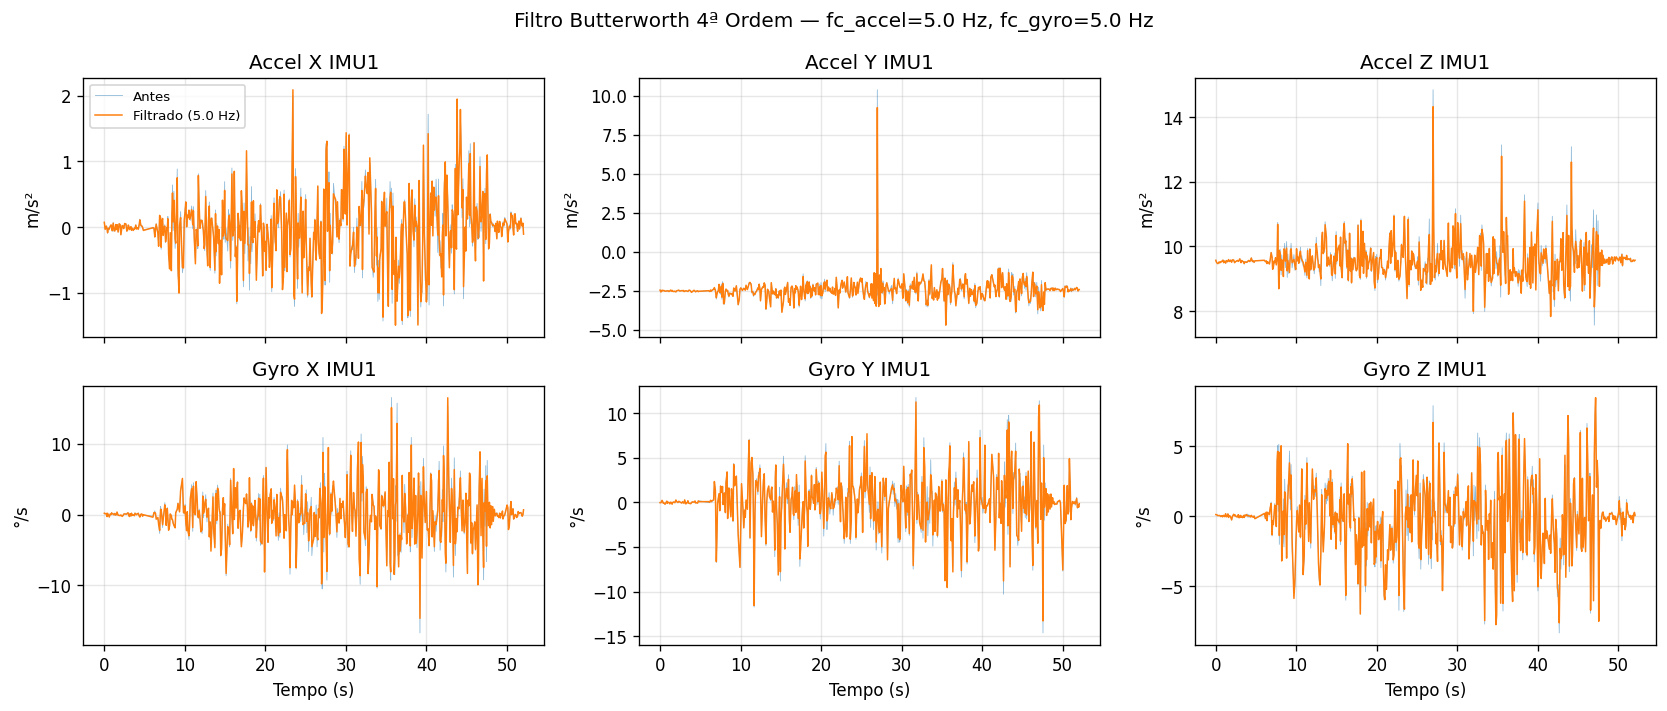

Filtro aplicado


In [31]:
def butter_lpf(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    sos = butter(order, min(cutoff, nyq*0.99)/nyq, btype='low', output='sos')
    return sosfiltfilt(sos, data)

# Aplicar filtro
ax1_f = butter_lpf(ax1_cal, FC_ACCEL, Fs);  ay1_f = butter_lpf(ay1_cal, FC_ACCEL, Fs)
az1_f = butter_lpf(az1_cal, FC_ACCEL, Fs)
ax2_f = butter_lpf(ax2_cal, FC_ACCEL, Fs);  ay2_f = butter_lpf(ay2_cal, FC_ACCEL, Fs)
az2_f = butter_lpf(az2_cal, FC_ACCEL, Fs)

gx1_f = butter_lpf(gx1_cal, FC_GYRO, Fs);  gy1_f = butter_lpf(gy1_cal, FC_GYRO, Fs)
gz1_f = butter_lpf(gz1_cal, FC_GYRO, Fs)
gx2_f = butter_lpf(gx2_cal, FC_GYRO, Fs);  gy2_f = butter_lpf(gy2_cal, FC_GYRO, Fs)
gz2_f = butter_lpf(gz2_cal, FC_GYRO, Fs)

# Plot antes/depois (IMU1)
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for i, (raw, filt, lbl) in enumerate(zip(
        [ax1_cal, ay1_cal, az1_cal], [ax1_f, ay1_f, az1_f], ['X','Y','Z'])):
    axes[0,i].plot(t, raw,  lw=0.5, alpha=0.5, label='Antes')
    axes[0,i].plot(t, filt, lw=0.9, label=f'Filtrado ({FC_ACCEL} Hz)')
    axes[0,i].set_title(f'Accel {lbl} IMU1'); axes[0,i].set_ylabel('m/s²')
    if i==0: axes[0,i].legend(fontsize=8)
for i, (raw, filt, lbl) in enumerate(zip(
        [gx1_cal, gy1_cal, gz1_cal], [gx1_f, gy1_f, gz1_f], ['X','Y','Z'])):
    axes[1,i].plot(t, np.degrees(raw),  lw=0.5, alpha=0.5)
    axes[1,i].plot(t, np.degrees(filt), lw=0.9)
    axes[1,i].set_title(f'Gyro {lbl} IMU1'); axes[1,i].set_ylabel('°/s')
    axes[1,i].set_xlabel('Tempo (s)')
fig.suptitle(f'Filtro Butterworth 4ª Ordem — fc_accel={FC_ACCEL} Hz, fc_gyro={FC_GYRO} Hz', fontsize=12)
plt.tight_layout(); plt.show()
print('Filtro aplicado')


## 6️⃣ Média dos Dois IMUs

Com dois IMUs independentes no mesmo corpo rígido, a média simples reduz o ruído por um fator de `√2`, sem custo computacional. A correção centrípeta/tangencial foi removida: o offset entre os IMUs (~4.5 cm) gera acelerações parasitas da ordem de `ω²·r ≈ (1 rad/s)²·0.045 m ≈ 0.045 m/s²`, abaixo da resolução espacial do flow (1 cm / 92 ms ≈ 0.11 m/s de threshold de detecção). Para o TCC, a simplificação é justificada.

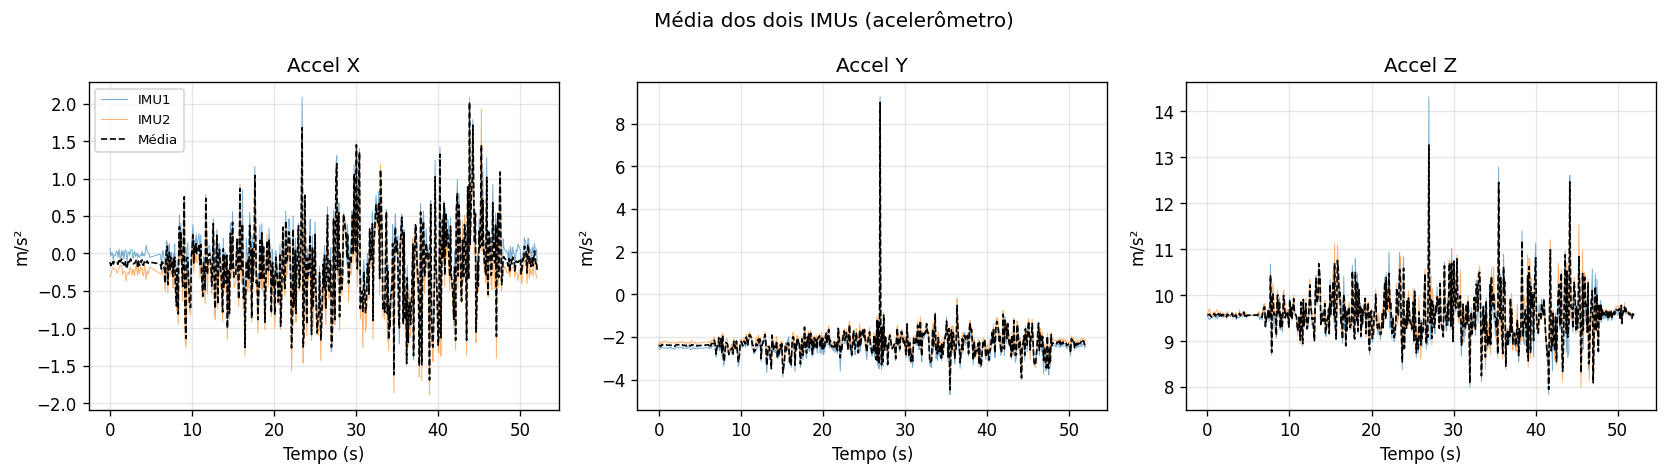

Média calculada


In [32]:
ax_avg = (ax1_f + ax2_f) / 2.0
ay_avg = (ay1_f + ay2_f) / 2.0
az_avg = (az1_f + az2_f) / 2.0

gx_avg = (gx1_f + gx2_f) / 2.0
gy_avg = (gy1_f + gy2_f) / 2.0
gz_avg = (gz1_f + gz2_f) / 2.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for i, (a1, a2, am, lbl) in enumerate(zip(
        [ax1_f, ay1_f, az1_f], [ax2_f, ay2_f, az2_f],
        [ax_avg, ay_avg, az_avg], ['X','Y','Z'])):
    axes[i].plot(t, a1, lw=0.6, alpha=0.6, label='IMU1')
    axes[i].plot(t, a2, lw=0.6, alpha=0.6, label='IMU2')
    axes[i].plot(t, am, lw=1.0, color='k', ls='--', label='Média')
    axes[i].set_title(f'Accel {lbl}'); axes[i].set_ylabel('m/s²')
    axes[i].set_xlabel('Tempo (s)')
    if i==0: axes[i].legend(fontsize=8)
fig.suptitle('Média dos dois IMUs (acelerômetro)', fontsize=12)
plt.tight_layout(); plt.show()
print('Média calculada')


## 7️⃣ Orientação — Filtro de Madgwick

Estima a orientação 3D como quaternion combinando giroscópio (integração) e acelerômetro (correção pela direção da gravidade). O parâmetro `β` é calculado automaticamente a partir do ruído RMS do giroscópio na janela de calibração.

In [33]:
# Beta automático
idx_cal = t < T_CALIB
gyro_rms = np.mean([gx_avg[idx_cal].std(), gy_avg[idx_cal].std(), gz_avg[idx_cal].std()])
MADGWICK_BETA = np.sqrt(3/4) * gyro_rms
print(f'Gyro RMS (calibração): {gyro_rms:.6f} rad/s')
print(f'Beta Madgwick: {MADGWICK_BETA:.6f}')


Gyro RMS (calibração): 0.001810 rad/s
Beta Madgwick: 0.001567


Rodando Madgwick (beta=0.00157)...
Rodando Madgwick (beta=0.00157)...
Quaternions calculados


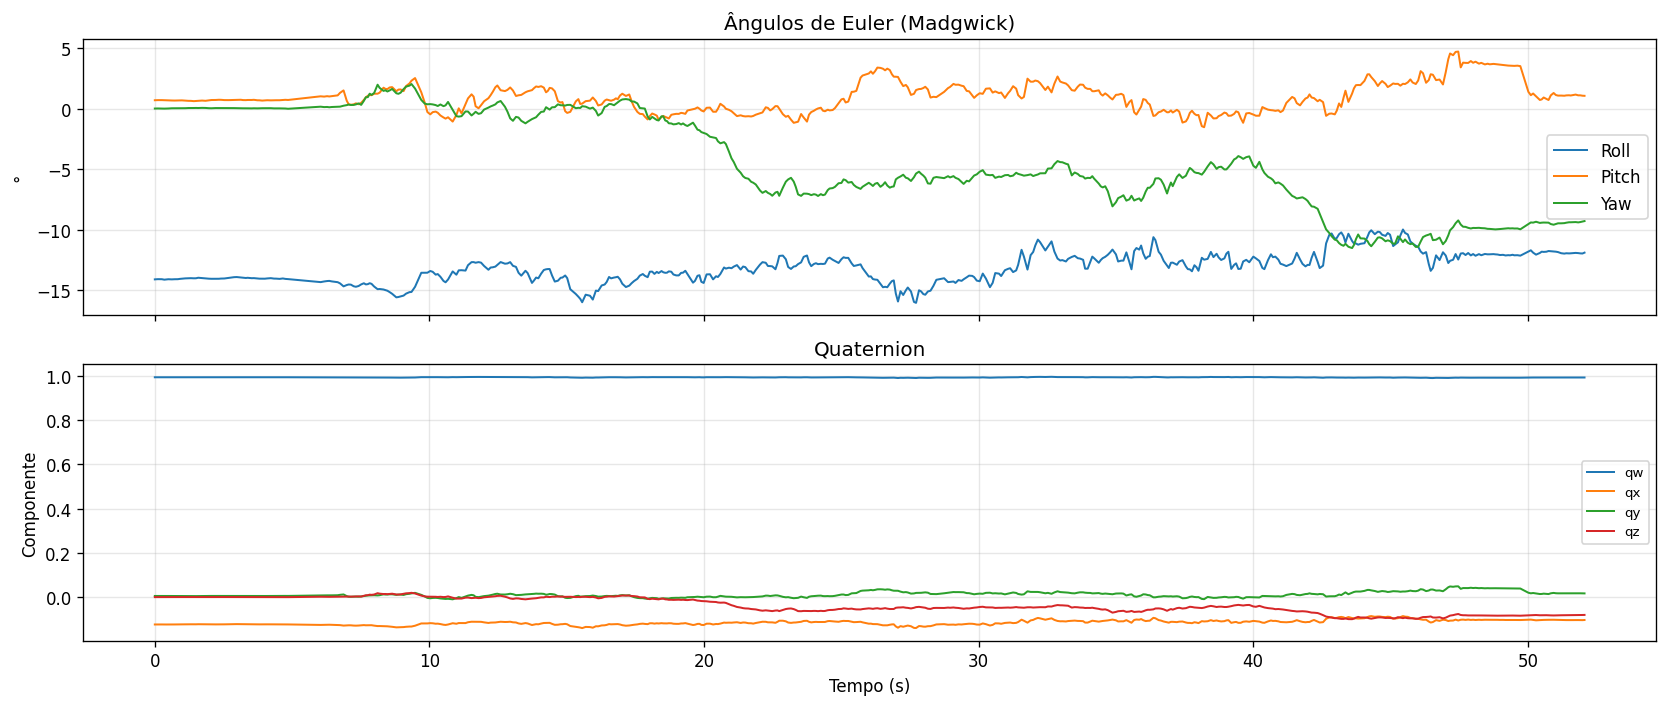

Roll=-11.9°  Pitch=1.1°  Yaw=-9.3°


In [34]:
def madgwick_update(q, gx, gy, gz, ax, ay, az, beta, dt):
    qw, qx, qy, qz = q
    norm_a = np.sqrt(ax*ax + ay*ay + az*az)
    if norm_a < 1e-9:
        qDot = 0.5 * np.array([-qx*gx-qy*gy-qz*gz, qw*gx+qy*gz-qz*gy,
                                qw*gy-qx*gz+qz*gx, qw*gz+qx*gy-qy*gx])
        q_new = np.array(q) + qDot*dt
        return q_new / np.linalg.norm(q_new)
    ax /= norm_a; ay /= norm_a; az /= norm_a
    F = np.array([2*(qx*qz - qw*qy) - ax,
                  2*(qw*qx + qy*qz) - ay,
                  2*(0.5 - qx**2 - qy**2) - az])
    J = np.array([[-2*qy, 2*qz, -2*qw, 2*qx],
                  [ 2*qx, 2*qw,  2*qz, 2*qy],
                  [ 0.0, -4*qx, -4*qy,  0.0]])
    grad = J.T @ F
    gn = np.linalg.norm(grad)
    if gn > 1e-9: grad /= gn
    qDot = 0.5*np.array([-qx*gx-qy*gy-qz*gz, qw*gx+qy*gz-qz*gy,
                          qw*gy-qx*gz+qz*gx, qw*gz+qx*gy-qy*gx]) - beta*grad
    q_new = np.array(q) + qDot*dt
    return q_new / np.linalg.norm(q_new)

print(f'Rodando Madgwick (beta={MADGWICK_BETA:.5f})...')
# Calcular atitude inicial baseada na gravidade (assumindo repouso no t=0)
ax0, ay0, az0 = ax_avg[0], ay_avg[0], az_avg[0]
roll0  = np.arctan2(ay0, az0)
pitch0 = np.arctan2(-ax0, np.sqrt(ay0**2 + az0**2))
yaw0   = 0.0  # Heading inicial arbitrário como 0

# Converter Euler inicial para Quaternion [qx, qy, qz, qw]
q0_scipy = Rot.from_euler('xyz', [roll0, pitch0, yaw0]).as_quat()

print(f'Rodando Madgwick (beta={MADGWICK_BETA:.5f})...')
quat = np.zeros((N, 4))
# Madgwick usa o formato [qw, qx, qy, qz], então precisamos reordenar
quat[0] = [q0_scipy[3], q0_scipy[0], q0_scipy[1], q0_scipy[2]]

for i in range(1, N):
    dt_i = t[i] - t[i-1]
    if dt_i <= 0:
        quat[i] = quat[i-1]; continue
    quat[i] = madgwick_update(quat[i-1],
                               gx_avg[i], gy_avg[i], gz_avg[i],
                               ax_avg[i], ay_avg[i], az_avg[i],
                               MADGWICK_BETA, dt_i)
print('Quaternions calculados')

euler = Rot.from_quat(np.column_stack([quat[:,1],quat[:,2],quat[:,3],quat[:,0]])).as_euler('xyz', degrees=True)
roll_deg, pitch_deg, yaw_deg = euler[:,0], euler[:,1], euler[:,2]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, roll_deg, label='Roll'); axes[0].plot(t, pitch_deg, label='Pitch')
axes[0].plot(t, yaw_deg, label='Yaw')
axes[0].set_ylabel('°'); axes[0].set_title('Ângulos de Euler (Madgwick)'); axes[0].legend()
axes[1].plot(t, quat[:,0], label='qw'); axes[1].plot(t, quat[:,1], label='qx')
axes[1].plot(t, quat[:,2], label='qy'); axes[1].plot(t, quat[:,3], label='qz')
axes[1].set_ylabel('Componente'); axes[1].set_title('Quaternion'); axes[1].legend(fontsize=8)
axes[1].set_xlabel('Tempo (s)')
plt.tight_layout(); plt.show()
print(f'Roll={roll_deg[-1]:.1f}°  Pitch={pitch_deg[-1]:.1f}°  Yaw={yaw_deg[-1]:.1f}°')


## 8. Aceleracao Linear no Referencial Mundo

Rotaciona o vetor de aceleracao do frame sensor para o frame mundo usando os quaternions do Madgwick, depois subtrai `g` no eixo vertical. Esta aceleracao linear e usada apenas como backup da IMU nos gaps do flow para a trajetoria **XY**.

O componente vertical e mantido apenas para diagnostico da remocao da gravidade; ele nao sera integrado para estimar posicao Z neste estudo.


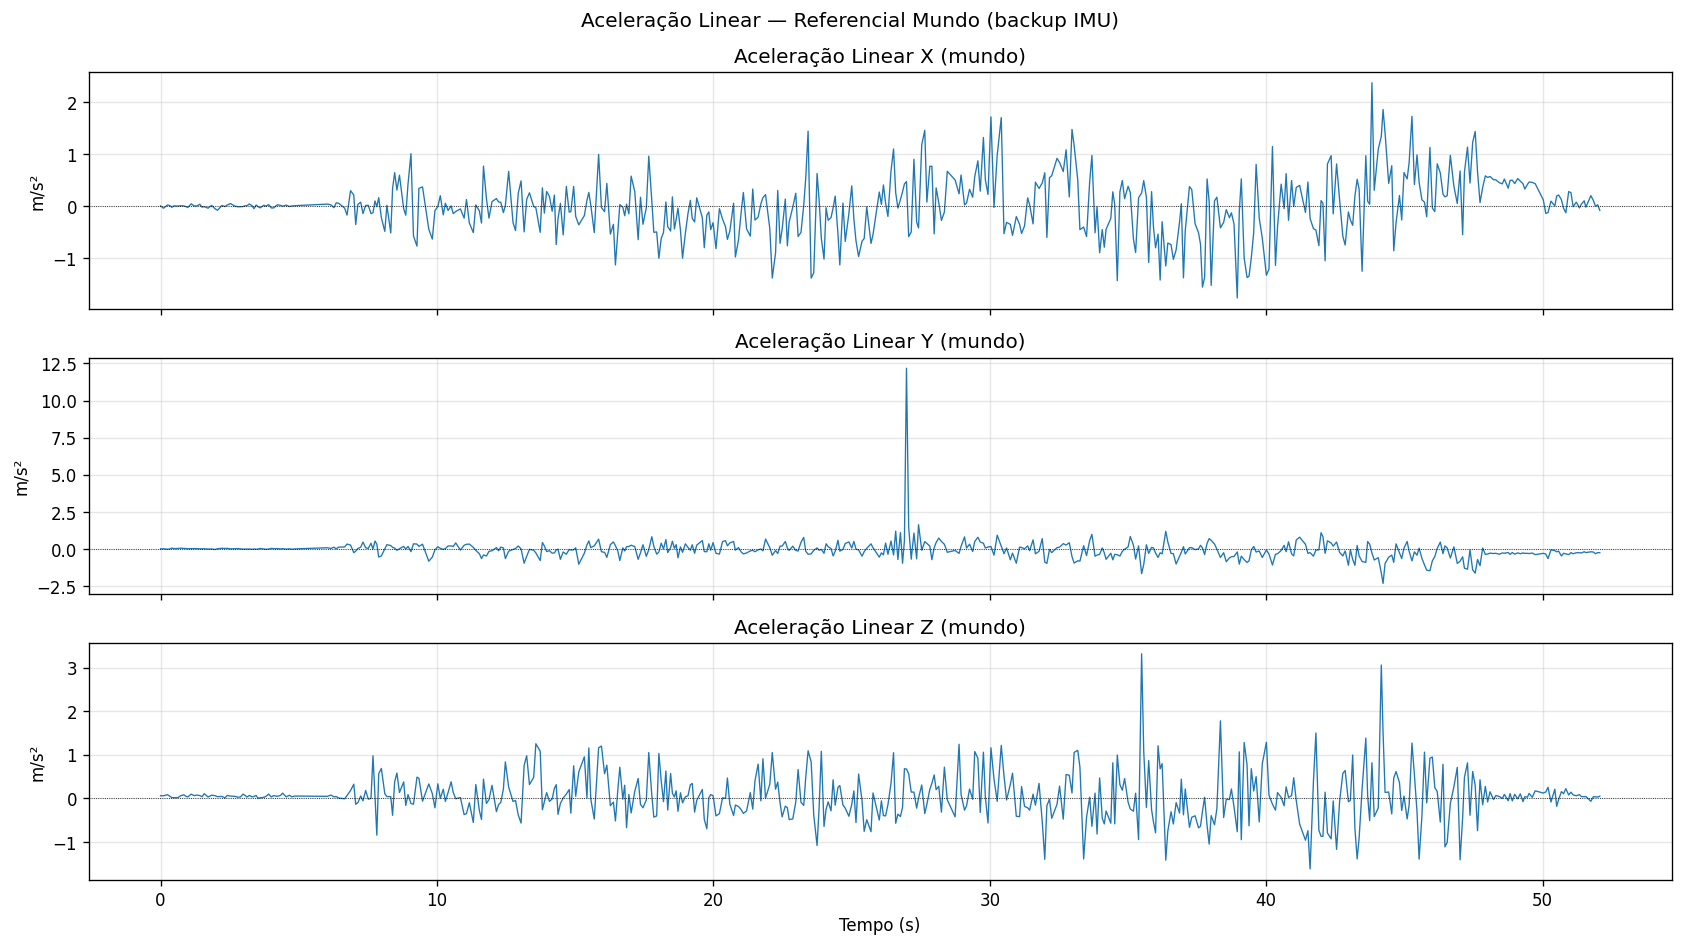

Aceleração residual estática: ax=-0.00470  ay=0.00120  az=0.04966 m/s²


In [35]:
accel_body = np.column_stack([ax_avg, ay_avg, az_avg])
rot_world  = Rot.from_quat(np.column_stack([quat[:,1],quat[:,2],quat[:,3],quat[:,0]]))
accel_world = rot_world.apply(accel_body)

ax_lin = accel_world[:, 0]
ay_lin = accel_world[:, 1]
az_lin = accel_world[:, 2] - G_NORM

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for i, (arr, lbl) in enumerate(zip([ax_lin, ay_lin, az_lin], ['X','Y','Z'])):
    axes[i].plot(t, arr, lw=0.8)
    axes[i].axhline(0, color='k', lw=0.5, ls=':')
    axes[i].set_ylabel('m/s²'); axes[i].set_title(f'Aceleração Linear {lbl} (mundo)')
axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Aceleração Linear — Referencial Mundo (backup IMU)', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Aceleração residual estática: ax={ax_lin[mask_calib].mean():.5f}  ay={ay_lin[mask_calib].mean():.5f}  az={az_lin[mask_calib].mean():.5f} m/s²')


## 9️⃣ Posição Primária — Flow Óptico + ToF

### Por que o flow é mais preciso que a IMU para posição

O sensor óptico mede deslocamento diretamente por correlação de imagem entre frames consecutivos. Seu erro acumula **linearmente** com a distância percorrida (tipicamente 1–3% da distância total). A IMU acumula ruído quadraticamente por dupla integração: para `σ_a = 0.01 m/s²` e `t = 30 s`, o erro posicional estimado é `½ × 0.01 × 30² ≈ 4.5 m` — muito superior ao deslocamento real medido pelo flow (~7 m).

### Limitação do flow

O sensor reporta apenas inteiros (resolução de 1 cm/amostra), o que implica velocidade mínima detectável de `1 cm / 92 ms ≈ 11 cm/s`. Movimentos mais lentos resultam em zeros consecutivos que **não significam repouso** — são um ponto cego do sensor. O IMU preenche esses gaps por dead reckoning.

### Correção de escala pelo ToF

Se o firmware usa uma altura fixa `h_nominal` para converter pixels em cm, mas a altura real é `h_real`, o deslocamento real é `d_real = d_nominal × (h_real / h_nominal)`. O ToF fornece `h_real` continuamente.

ToF válido: 520 de 520 amostras (100.0%)
Altura média: 89.4 mm ± 3.1 mm

Eventos de flow: 97 (18.7% das amostras)
Trajetória flow: x=0.237 m  y=7.191 m


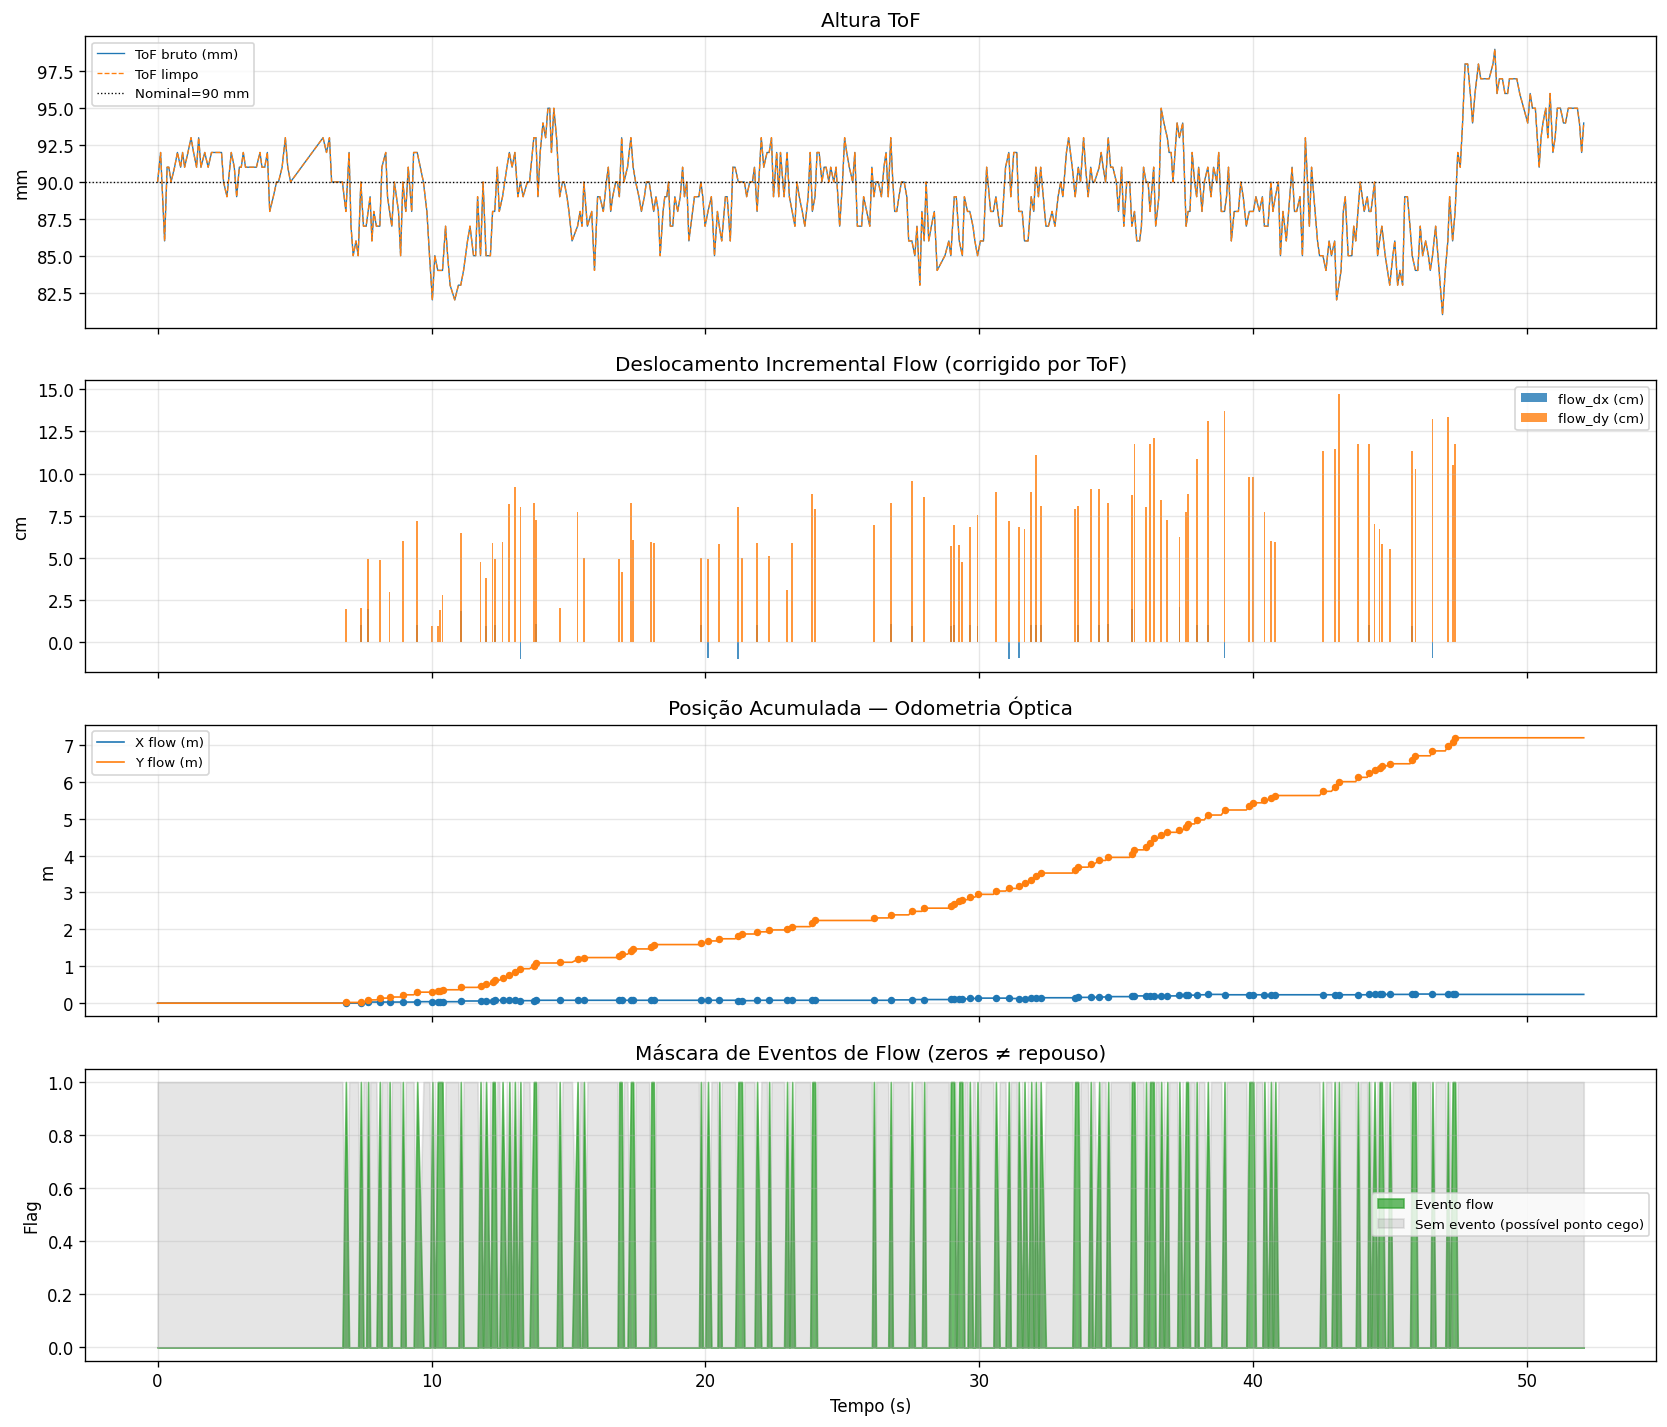

Sensor optico primario pronto


In [36]:
# ── Extrair e validar ToF ─────────────────────────────────────────────────
tof_raw  = df['tof_mm'].values.astype(float)
tof_mask = (tof_raw >= TOF_VALID_MIN_MM) & (tof_raw <= TOF_VALID_MAX_MM)
tof_clean = np.where(tof_mask, tof_raw, TOF_NOMINAL_MM)

print(f'ToF válido: {tof_mask.sum()} de {N} amostras ({100*tof_mask.mean():.1f}%)')
print(f'Altura média: {tof_clean.mean():.1f} mm ± {tof_clean.std():.1f} mm')

# ── Correção de escala pelo ToF ───────────────────────────────────────────
scale_tof = tof_clean / TOF_NOMINAL_MM  # ≈ 1 quando altura é estável

flow_dx_raw = df['flow_dx'].values.astype(float)
flow_dy_raw = df['flow_dy'].values.astype(float)

flow_dx = flow_dx_raw * scale_tof  # cm, corrigido pela altura real
flow_dy = flow_dy_raw * scale_tof  # cm

# ── Mapeamento de eixos flow → mundo ─────────────────────────────────────
sign_x = -1.0 if FLOW_AXIS_X.startswith('-') else 1.0
sign_y = -1.0 if FLOW_AXIS_Y.startswith('-') else 1.0
flow_dx *= sign_x
flow_dy *= sign_y

# ── Posição acumulada (odometria óptica) ──────────────────────────────────
flow_px = np.cumsum(flow_dx) / 100.0  # m
flow_py = np.cumsum(flow_dy) / 100.0  # m

# Máscara de eventos (resolução de 1 cm — zeros não garantem repouso)
flow_event = (flow_dx != 0) | (flow_dy != 0)
ev_idx = np.where(flow_event)[0]

print(f'\nEventos de flow: {flow_event.sum()} ({100*flow_event.mean():.1f}% das amostras)')
print(f'Trajetória flow: x={flow_px[-1]:.3f} m  y={flow_py[-1]:.3f} m')

# ── Plot diagnóstico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, tof_raw,   lw=0.8, label='ToF bruto (mm)')
axes[0].plot(t, tof_clean, lw=0.8, ls='--', label='ToF limpo')
axes[0].axhline(TOF_NOMINAL_MM, color='k', ls=':', lw=0.8, label=f'Nominal={TOF_NOMINAL_MM:.0f} mm')
axes[0].set_ylabel('mm'); axes[0].set_title('Altura ToF'); axes[0].legend(fontsize=8)

w = np.median(np.diff(t)) * 0.7
axes[1].bar(t, flow_dx, width=w, color='tab:blue',   alpha=0.8, label='flow_dx (cm)')
axes[1].bar(t, flow_dy, width=w, color='tab:orange', alpha=0.8, label='flow_dy (cm)')
axes[1].set_ylabel('cm'); axes[1].set_title('Deslocamento Incremental Flow (corrigido por ToF)')
axes[1].legend(fontsize=8)

axes[2].plot(t, flow_px, lw=1.0, label='X flow (m)')
axes[2].plot(t, flow_py, lw=1.0, label='Y flow (m)')
axes[2].scatter(t[ev_idx], flow_px[ev_idx], s=12, color='tab:blue',   zorder=5)
axes[2].scatter(t[ev_idx], flow_py[ev_idx], s=12, color='tab:orange', zorder=5)
axes[2].set_ylabel('m'); axes[2].set_title('Posição Acumulada — Odometria Óptica')
axes[2].legend(fontsize=8)

axes[3].fill_between(t, 0, flow_event.astype(float),  color='tab:green', alpha=0.7, label='Evento flow')
axes[3].fill_between(t, 0, (~flow_event).astype(float), color='gray', alpha=0.2, label='Sem evento (possível ponto cego)')
axes[3].set_ylabel('Flag'); axes[3].set_title('Máscara de Eventos de Flow (zeros ≠ repouso)')
axes[3].set_xlabel('Tempo (s)'); axes[3].legend(fontsize=8)

plt.tight_layout(); plt.show()
print('Sensor optico primario pronto')


## 10. Delimitacao do Eixo Z

A posicao no eixo Z foi retirada do estudo. O sensor optico disponivel mede o deslocamento relativo observado no plano horizontal do drone, portanto fornece informacao direta para os eixos **X** e **Y**.

Para obter uma posicao precisa no eixo **Z**, seria necessario adicionar outro sensor optico orientado para observar o plano **XZ** em relacao ao drone. Esse segundo sensor permitiria medir deslocamentos verticais por correlacao de imagem, de forma analoga ao flow usado no plano XY.

O ToF continua sendo usado somente para estimar a distancia ao solo e corrigir a escala do flow optico. Ele nao e tratado como odometria vertical, porque uma medida de distancia pontual ao solo nao resolve, sozinha, a trajetoria precisa no eixo Z quando ha inclinacao, variacao do relevo ou mudancas na geometria de medicao.


In [37]:
# O eixo Z foi retirado do estudo de posicao.
# O ToF permanece disponivel apenas como medida auxiliar de escala usada no flow XY.
print('Eixo Z excluido da estimativa de posicao; analise restrita ao plano XY.')


Eixo Z excluido da estimativa de posicao; analise restrita ao plano XY.


## 1️⃣1️⃣ Dead Reckoning IMU nos Gaps do Flow

Nos intervalos entre eventos de flow, o sensor óptico não fornece informação posicional. O IMU realiza **dead reckoning**: integra a aceleração linear para obter velocidade, e integra a velocidade para obter deslocamento incremental relativo ao último ponto de flow conhecido.

**Âncoragem:** ao final de cada gap, o deslocamento estimado pelo IMU é escalonado linearmente para que a trajetória chegue exatamente ao próximo ponto de flow. Isso elimina o drift absoluto do IMU — ele só precisa ser preciso **dentro do gap**, não acumulado ao longo de toda a trajetória.

**Equação de ancoragem:**

```
p_imu_gap(t) = p_flow_start + (p_imu_raw(t) - p_imu_raw(t_start))
                × (p_flow_end - p_flow_start) / (p_imu_raw(t_end) - p_imu_raw(t_start))
```

Se o IMU estimar deslocamento zero num gap (aceleração muito baixa), faz-se interpolação linear direta entre os dois pontos de flow vizinhos.

> **Justificativa técnica:** Esta é a arquitetura de navegação usada em drones de baixo custo com PX4/ArduPilot, onde o flow óptico é o sensor primário de posição XY e a IMU faz propagação de estado entre frames do sensor óptico (tipicamente 20–100 Hz para o flow, 400–1000 Hz para a IMU).

Calculando trajetória XY fusionada (flow + dead reckoning IMU)...
Trajetória final:
  Flow puro:  x=0.237 m  y=7.191 m
  Fusionado:  x=0.237 m  y=7.191 m


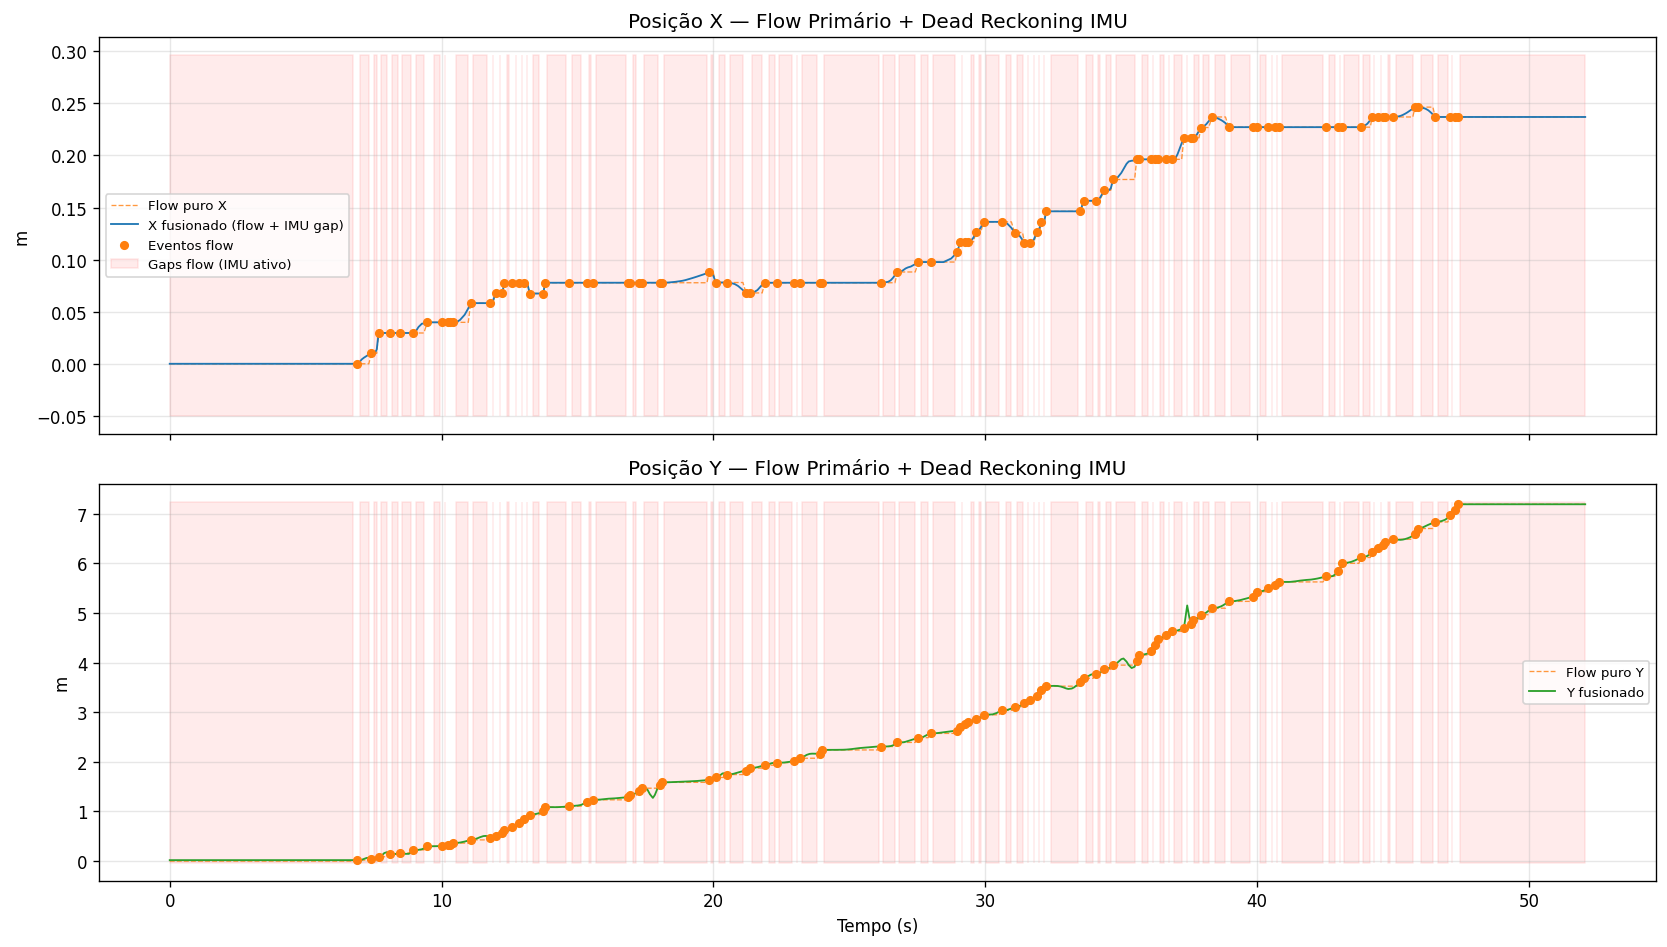

Trajetória fusionada calculada


In [38]:
def dead_reckon_gaps(t_arr, ax, ay, flow_px, flow_py, ev_idx):
    """
    Constrói trajetória XY usando:
    - Pontos de flow nos instantes ev_idx (posição absoluta conhecida)
    - Integração IMU para interpolar entre eventos (dead reckoning âncado)

    Retorna px_fused, py_fused de tamanho N.
    """
    N = len(t_arr)
    px_out = np.full(N, np.nan)
    py_out = np.full(N, np.nan)

    # Ancorar nos pontos de flow
    for idx in ev_idx:
        px_out[idx] = flow_px[idx]
        py_out[idx] = flow_py[idx]

    # Antes do primeiro evento: usar posição do primeiro ponto de flow
    if len(ev_idx) > 0:
        px_out[:ev_idx[0]+1] = flow_px[ev_idx[0]]
        py_out[:ev_idx[0]+1] = flow_py[ev_idx[0]]

    # Após o último evento: dead reckoning livre (IMU) — o drift é pequeno num gap curto
    # Para o final da série usamos interpolação linear do último evento
    if len(ev_idx) > 0:
        px_out[ev_idx[-1]:] = flow_px[ev_idx[-1]]
        py_out[ev_idx[-1]:] = flow_py[ev_idx[-1]]

    # Preencher gaps entre eventos consecutivos
    for k in range(len(ev_idx) - 1):
        i_start = ev_idx[k]
        i_end   = ev_idx[k+1]
        if i_end - i_start <= 1:
            continue

        # Posições de flow nas extremidades do gap
        px_s, px_e = flow_px[i_start], flow_px[i_end]
        py_s, py_e = flow_py[i_start], flow_py[i_end]

        # Integração trapezoidal da aceleração IMU dentro do gap
        seg = slice(i_start, i_end+1)
        t_seg = t_arr[seg]
        ax_seg = ax[seg]
        ay_seg = ay[seg]
        n_seg  = len(t_seg)

        vx_seg = np.zeros(n_seg)
        vy_seg = np.zeros(n_seg)
        for j in range(1, n_seg):
            dt_j = t_seg[j] - t_seg[j-1]
            if dt_j <= 0: continue
            vx_seg[j] = vx_seg[j-1] + 0.5*(ax_seg[j-1]+ax_seg[j])*dt_j
            vy_seg[j] = vy_seg[j-1] + 0.5*(ay_seg[j-1]+ay_seg[j])*dt_j

        dx_imu = np.zeros(n_seg)
        dy_imu = np.zeros(n_seg)
        for j in range(1, n_seg):
            dt_j = t_seg[j] - t_seg[j-1]
            if dt_j <= 0: continue
            dx_imu[j] = dx_imu[j-1] + 0.5*(vx_seg[j-1]+vx_seg[j])*dt_j
            dy_imu[j] = dy_imu[j-1] + 0.5*(vy_seg[j-1]+vy_seg[j])*dt_j

        # Âncoragem: escalar trajetória IMU para que termine no próximo ponto de flow
        dx_imu_total = dx_imu[-1]
        dy_imu_total = dy_imu[-1]

        if abs(dx_imu_total) > 1e-6:
            scale_x = (px_e - px_s) / dx_imu_total
        else:
            scale_x = 0.0  # fallback: interpolação linear

        if abs(dy_imu_total) > 1e-6:
            scale_y = (py_e - py_s) / dy_imu_total
        else:
            scale_y = 0.0

        # Se IMU estimou deslocamento nulo: interpolação linear entre pontos de flow
        frac = (t_seg - t_seg[0]) / max(t_seg[-1] - t_seg[0], 1e-9)

        if abs(scale_x) < 1e-6:
            px_gap = px_s + frac * (px_e - px_s)
        else:
            px_gap = px_s + dx_imu * scale_x

        if abs(scale_y) < 1e-6:
            py_gap = py_s + frac * (py_e - py_s)
        else:
            py_gap = py_s + dy_imu * scale_y

        px_out[i_start:i_end+1] = px_gap
        py_out[i_start:i_end+1] = py_gap

    # Preencher NaN residuais por interpolação
    nan_mask = np.isnan(px_out)
    if nan_mask.any():
        idx_valid = np.where(~nan_mask)[0]
        px_out = np.interp(np.arange(N), idx_valid, px_out[idx_valid])
        py_out = np.interp(np.arange(N), idx_valid, py_out[idx_valid])

    return px_out, py_out


print('Calculando trajetória XY fusionada (flow + dead reckoning IMU)...')
px_fused, py_fused = dead_reckon_gaps(t, ax_lin, ay_lin, flow_px, flow_py, ev_idx)
print(f'Trajetória final:')
print(f'  Flow puro:  x={flow_px[-1]:.3f} m  y={flow_py[-1]:.3f} m')
print(f'  Fusionado:  x={px_fused[-1]:.3f} m  y={py_fused[-1]:.3f} m')

# ── Diagnóstico ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, flow_px, lw=0.8, ls='--', color='tab:orange', label='Flow puro X', alpha=0.8)
axes[0].plot(t, px_fused, lw=1.1, color='tab:blue', label='X fusionado (flow + IMU gap)')
axes[0].scatter(t[ev_idx], flow_px[ev_idx], s=20, color='tab:orange', zorder=5, label='Eventos flow')
axes[0].fill_between(t, px_fused.min()-0.05, px_fused.max()+0.05,
                     where=~flow_event, alpha=0.08, color='red', label='Gaps flow (IMU ativo)')
axes[0].set_ylabel('m'); axes[0].set_title('Posição X — Flow Primário + Dead Reckoning IMU')
axes[0].legend(fontsize=8)

axes[1].plot(t, flow_py, lw=0.8, ls='--', color='tab:orange', label='Flow puro Y', alpha=0.8)
axes[1].plot(t, py_fused, lw=1.1, color='tab:green', label='Y fusionado')
axes[1].scatter(t[ev_idx], flow_py[ev_idx], s=20, color='tab:orange', zorder=5)
axes[1].fill_between(t, py_fused.min()-0.05, py_fused.max()+0.05,
                     where=~flow_event, alpha=0.08, color='red')
axes[1].set_ylabel('m'); axes[1].set_title('Posição Y — Flow Primário + Dead Reckoning IMU')
axes[1].set_xlabel('Tempo (s)'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()
print('Trajetória fusionada calculada')


In [ ]:
# ── Exportar posição para cada medição LiDAR ───────────────────────────────
# O pipeline calcula posição/atitude em timestamps únicos, mas o arquivo bruto
# tem várias medições LiDAR (angle, distance, intensity) para o mesmo tempo_us.
# Aqui replicamos a posição e a atitude calculadas para cada medição original.
state_cols = ['x', 'y', 'angle_x', 'angle_y', 'angle_z']
state_by_time = pd.DataFrame({
    'tempo_us': df['tempo_us'].values,
    'x': px_fused,
    'y': py_fused,
    'angle_x': roll_deg,
    'angle_y': pitch_deg,
    'angle_z': yaw_deg,
})

lidar_cols = ['tempo_us', 'angle', 'distance', 'intensity']
missing_cols = [col for col in lidar_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Colunas LiDAR ausentes no CSV original: {missing_cols}')

lidar_raw = df_raw[lidar_cols].copy()
lidar_raw['_row_order'] = np.arange(len(lidar_raw))

saida_posicao_lidar = lidar_raw.merge(state_by_time, on='tempo_us', how='left', sort=False)

# Se houver algum timestamp bruto fora da série usada pelo pipeline, usar a posição e a atitude
# temporal mais próxima para não deixar x/y/ângulos vazios na saída final.
missing_state = saida_posicao_lidar['x'].isna()
if missing_state.any():
    nearest_state = pd.merge_asof(
        lidar_raw.loc[missing_state].sort_values('tempo_us'),
        state_by_time.sort_values('tempo_us'),
        on='tempo_us',
        direction='nearest',
    ).set_index('_row_order')
    saida_posicao_lidar = saida_posicao_lidar.set_index('_row_order')
    saida_posicao_lidar.loc[nearest_state.index, state_cols] = nearest_state[state_cols]
    saida_posicao_lidar = saida_posicao_lidar.reset_index()

saida_posicao_lidar = (
    saida_posicao_lidar
    .sort_values('_row_order')
    [['tempo_us', 'x', 'y', 'angle_x', 'angle_y', 'angle_z', 'angle', 'distance', 'intensity']]
)

OUTPUT_CSV = './posicoes_lidar_imu.csv'
saida_posicao_lidar.to_csv(OUTPUT_CSV, index=False)

print(f'CSV exportado: {OUTPUT_CSV}')
print(f'Linhas exportadas: {len(saida_posicao_lidar):,} (mesmo total do CSV original: {len(df_raw):,})')
print(f'Timestamps preenchidos pela posição e atitude mais próximas: {missing_state.sum():,}')
print(f'Timestamps sem posição após preenchimento: {saida_posicao_lidar["x"].isna().sum():,}')
display(saida_posicao_lidar.head())


## 12. Trajetoria Final - Visualizacao 2D


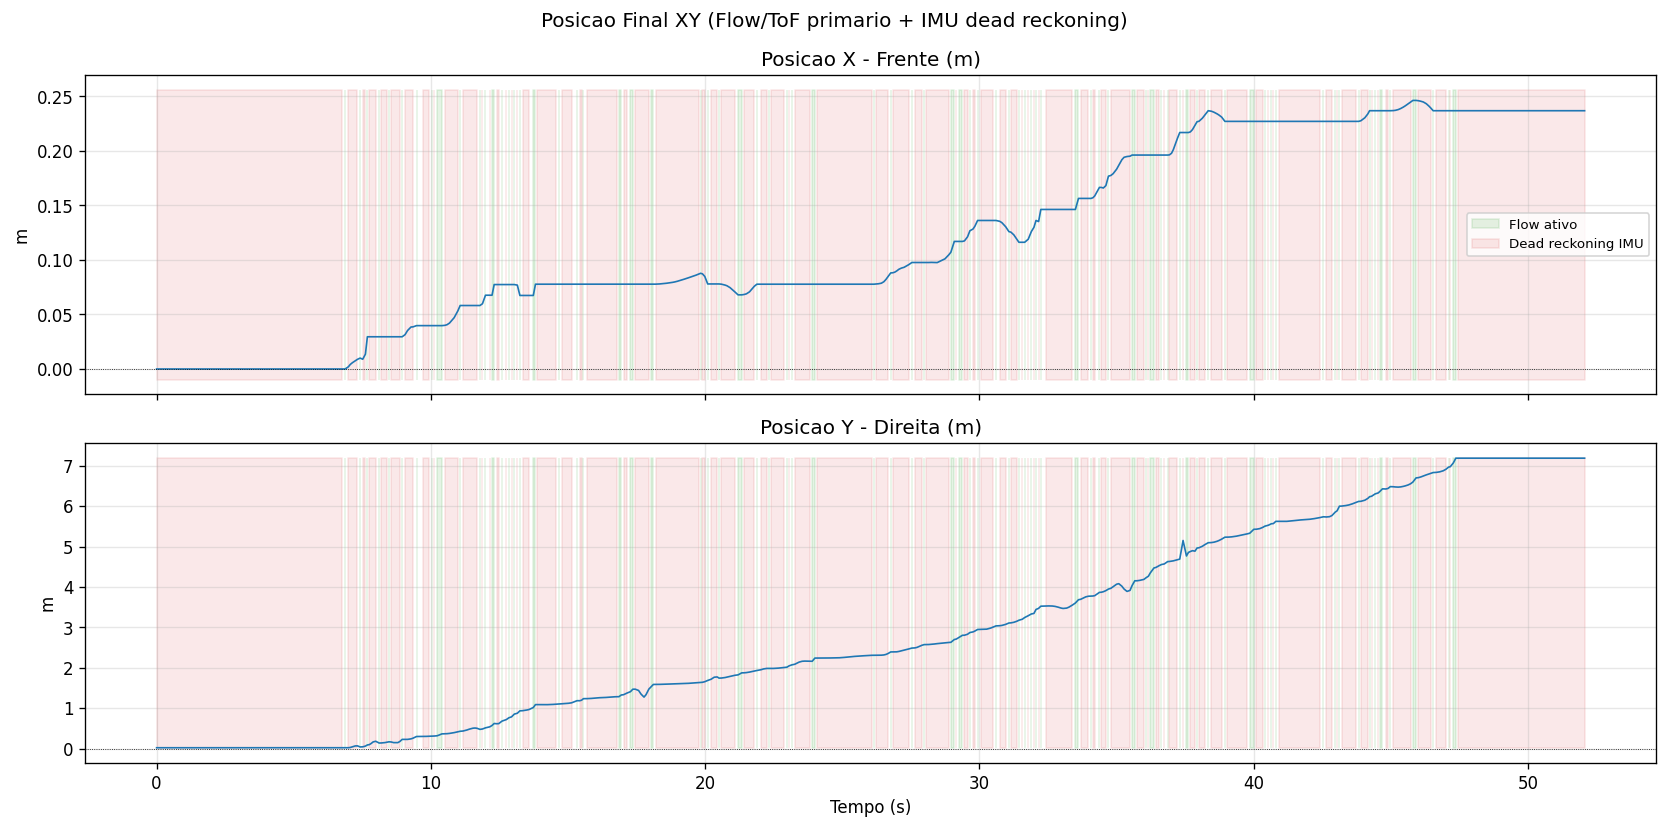

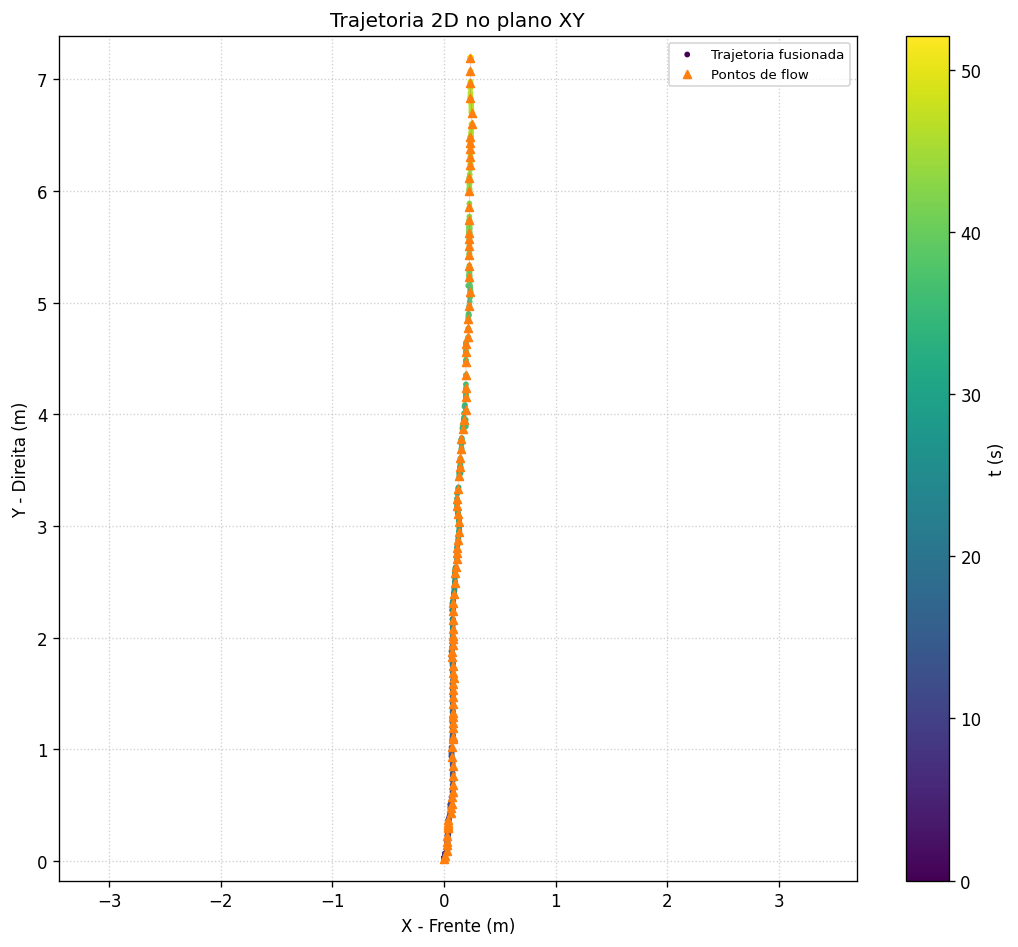

Deslocamento final: x=0.237 m  y=7.191 m
Distancia total percorrida no plano XY: 9.281 m
Fracao da trajetoria coberta pelo flow: 18.7%
Fracao coberta por dead reckoning IMU: 81.3%


In [39]:
# Posicao ao longo do tempo - apenas eixos X e Y
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax_, arr, lbl in zip(axes, [px_fused, py_fused], ['X - Frente (m)', 'Y - Direita (m)']):
    ax_.plot(t, arr, lw=1.0)
    ax_.fill_between(t, arr.min()-0.01, arr.max()+0.01,
                     where=flow_event, alpha=0.12, color='tab:green', label='Flow ativo')
    ax_.fill_between(t, arr.min()-0.01, arr.max()+0.01,
                     where=~flow_event, alpha=0.10, color='tab:red', label='Dead reckoning IMU')
    ax_.axhline(0, color='k', lw=0.5, ls=':')
    ax_.set_ylabel('m')
    ax_.set_title(f'Posicao {lbl}')
axes[0].legend(fontsize=8)
axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Posicao Final XY (Flow/ToF primario + IMU dead reckoning)', fontsize=12)
plt.tight_layout(); plt.show()

# Trajetoria no plano XY
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(px_fused, py_fused, c=t, cmap='viridis', s=6, label='Trajetoria fusionada')
ax.plot(px_fused, py_fused, lw=0.4, color='gray', alpha=0.45)
ax.scatter(flow_px[ev_idx], flow_py[ev_idx], s=22, color='tab:orange', marker='^', zorder=5, label='Pontos de flow')
ax.set_xlabel('X - Frente (m)')
ax.set_ylabel('Y - Direita (m)')
ax.set_title('Trajetoria 2D no plano XY')
ax.set_aspect('equal', adjustable='datalim')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='t (s)')
plt.tight_layout(); plt.show()

print(f'Deslocamento final: x={px_fused[-1]:.3f} m  y={py_fused[-1]:.3f} m')
dist_total_xy = np.sum(np.sqrt(np.diff(px_fused)**2 + np.diff(py_fused)**2))
print(f'Distancia total percorrida no plano XY: {dist_total_xy:.3f} m')
frac_flow = flow_event.mean()
print(f'Fracao da trajetoria coberta pelo flow: {100*frac_flow:.1f}%')
print(f'Fracao coberta por dead reckoning IMU: {100*(1-frac_flow):.1f}%')


## 📊 Painel de Resumo

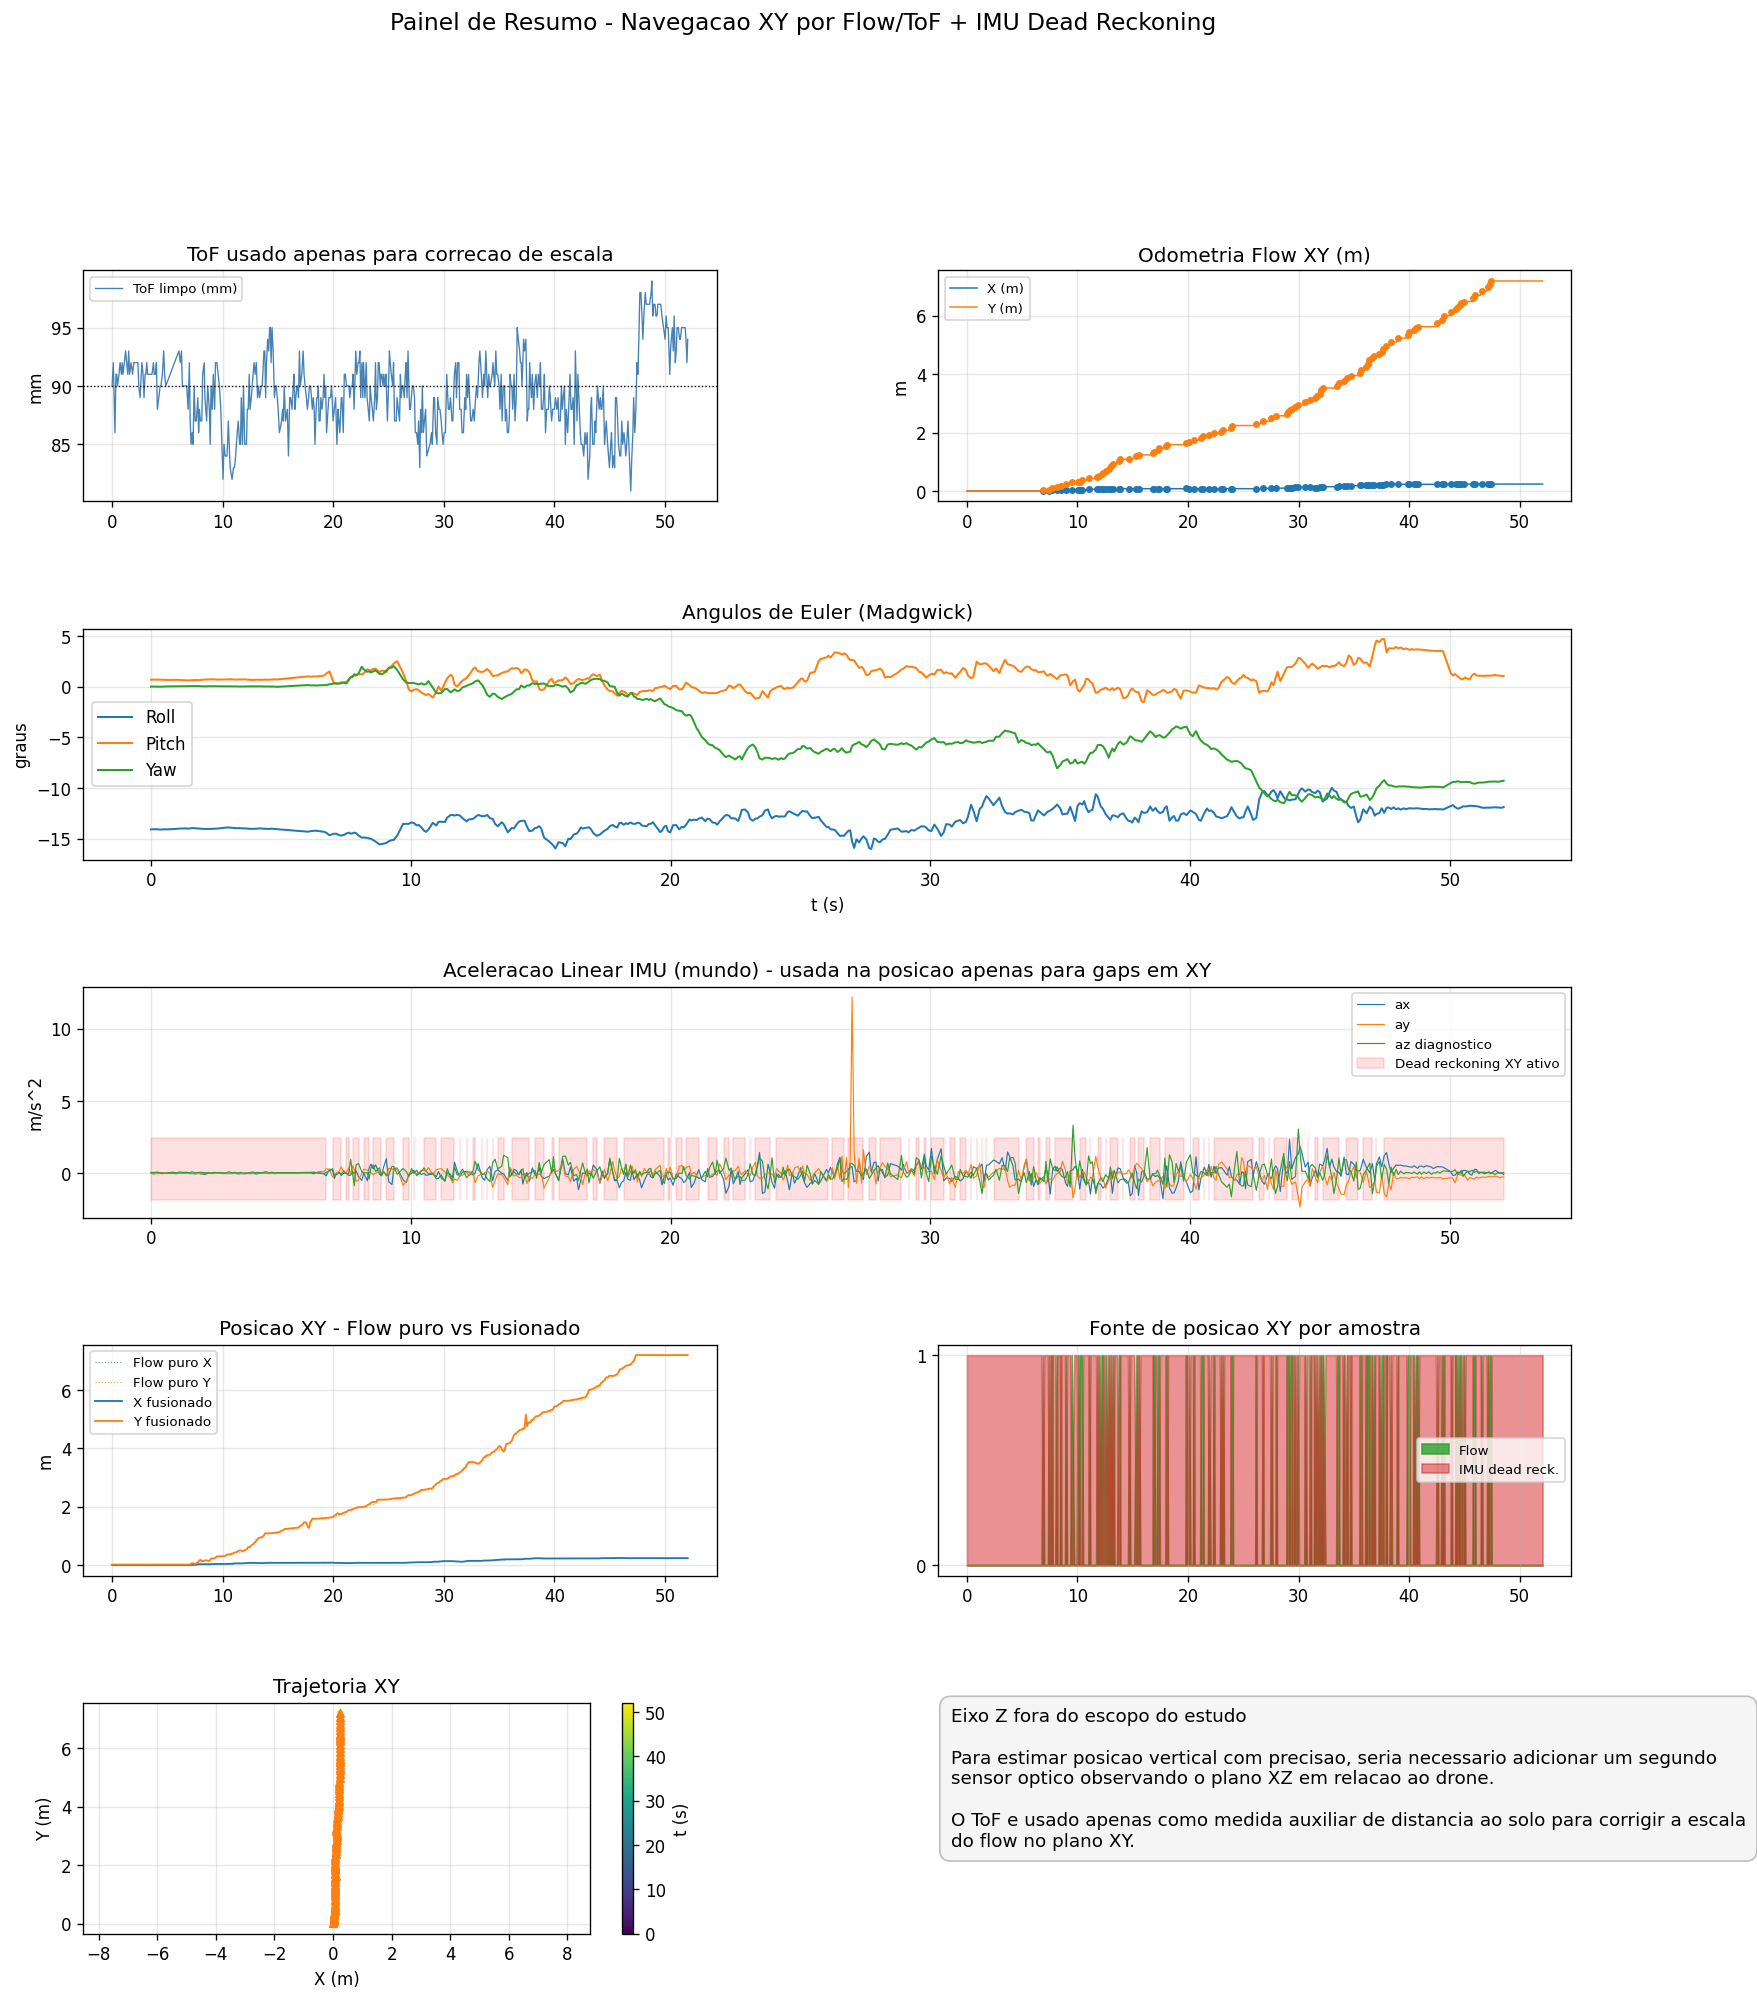

Pipeline concluido!


In [40]:
fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.35)

# Linha 0: ToF + Flow eventos
ax_ = fig.add_subplot(gs[0, 0])
ax_.plot(t, tof_clean, lw=0.8, color='steelblue', label='ToF limpo (mm)')
ax_.axhline(TOF_NOMINAL_MM, color='k', ls=':', lw=0.8)
ax_.set_title('ToF usado apenas para correcao de escala'); ax_.set_ylabel('mm'); ax_.legend(fontsize=8)

ax_ = fig.add_subplot(gs[0, 1])
ax_.plot(t, flow_px, lw=0.9, label='X (m)', color='tab:blue')
ax_.plot(t, flow_py, lw=0.9, label='Y (m)', color='tab:orange')
ax_.scatter(t[ev_idx], flow_px[ev_idx], s=10, color='tab:blue',   zorder=5)
ax_.scatter(t[ev_idx], flow_py[ev_idx], s=10, color='tab:orange', zorder=5)
ax_.set_title('Odometria Flow XY (m)'); ax_.set_ylabel('m'); ax_.legend(fontsize=8)

# Linha 1: Angulos de Euler
ax_ = fig.add_subplot(gs[1, :])
ax_.plot(t, roll_deg, label='Roll'); ax_.plot(t, pitch_deg, label='Pitch')
ax_.plot(t, yaw_deg, label='Yaw')
ax_.set_title('Angulos de Euler (Madgwick)'); ax_.set_ylabel('graus')
ax_.legend(); ax_.set_xlabel('t (s)')

# Linha 2: Aceleracao linear (backup IMU)
ax_ = fig.add_subplot(gs[2, :])
ax_.plot(t, ax_lin, lw=0.7, label='ax'); ax_.plot(t, ay_lin, lw=0.7, label='ay')
ax_.plot(t, az_lin, lw=0.7, label='az diagnostico')
ax_.fill_between(t, ax_lin.min()-0.1, ax_lin.max()+0.1,
                 where=~flow_event, alpha=0.12, color='red', label='Dead reckoning XY ativo')
ax_.set_title('Aceleracao Linear IMU (mundo) - usada na posicao apenas para gaps em XY')
ax_.set_ylabel('m/s^2'); ax_.legend(fontsize=8)

# Linha 3: Posicao X e Y comparacao + mascara de fonte
ax_ = fig.add_subplot(gs[3, 0])
ax_.plot(t, flow_px, lw=0.7, ls=':', alpha=0.7, label='Flow puro X')
ax_.plot(t, flow_py, lw=0.7, ls=':', alpha=0.7, label='Flow puro Y')
ax_.plot(t, px_fused, lw=1.1, label='X fusionado', color='tab:blue')
ax_.plot(t, py_fused, lw=1.1, label='Y fusionado', color='tab:orange')
ax_.set_title('Posicao XY - Flow puro vs Fusionado'); ax_.set_ylabel('m')
ax_.legend(fontsize=8)

ax_ = fig.add_subplot(gs[3, 1])
ax_.fill_between(t, 0, flow_event.astype(float),  color='tab:green', alpha=0.8, label='Flow')
ax_.fill_between(t, 0, (~flow_event).astype(float), color='tab:red', alpha=0.5, label='IMU dead reck.')
ax_.set_title('Fonte de posicao XY por amostra')
ax_.set_yticks([0,1]); ax_.legend(fontsize=8)

# Linha 4: Trajetoria XY + nota metodologica sobre Z
ax_ = fig.add_subplot(gs[4, 0])
sc = ax_.scatter(px_fused, py_fused, c=t, cmap='viridis', s=5)
ax_.plot(px_fused, py_fused, lw=0.3, color='gray', alpha=0.4)
ax_.scatter(flow_px[ev_idx], flow_py[ev_idx], s=20, color='tab:orange', marker='^', zorder=5)
ax_.set_xlabel('X (m)'); ax_.set_ylabel('Y (m)')
ax_.set_title('Trajetoria XY'); ax_.set_aspect('equal', adjustable='datalim')
plt.colorbar(sc, ax=ax_, label='t (s)')

ax_ = fig.add_subplot(gs[4, 1])
ax_.axis('off')
nota_z = (
    'Eixo Z fora do escopo do estudo\n\n'
    'Para estimar posicao vertical com precisao, seria necessario adicionar '
    'um segundo sensor optico observando o plano XZ em relacao ao drone.\n\n'
    'O ToF e usado apenas como medida auxiliar de distancia ao solo para '
    'corrigir a escala do flow no plano XY.'
)
ax_.text(0.02, 0.98, nota_z, va='top', ha='left', fontsize=11, wrap=True,
         bbox=dict(boxstyle='round,pad=0.6', facecolor='whitesmoke', edgecolor='0.75'))

fig.suptitle('Painel de Resumo - Navegacao XY por Flow/ToF + IMU Dead Reckoning', fontsize=14, y=1.0)
plt.savefig('./imu_flow_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('Pipeline concluido!')
